In [19]:
!pip install tensorflow

In [20]:
!pip install pmdarima

In [21]:
# ===============================================================
# 🧠 STEP 1: Import Libraries and Set Seeds
# ===============================================================

print("="*70)
print("🧠 STEP 1 START: Importing libraries and setting seeds...")
print("="*70)

import sys
!{sys.executable} -m pip install tensorflow keras-tcn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import timedelta
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# External package: keras-tcn
from tcn import TCN

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ STEP 1 COMPLETE")

🧠 STEP 1 START: Importing libraries and setting seeds...
✅ STEP 1 COMPLETE


In [22]:
# ===============================================================
# 🧠 STEP 2: Load and Preprocess EV Charging Data
# ===============================================================

print("="*70)
print("🧠 STEP 2 START: Loading and preprocessing EV charging data...")
print("="*70)

# ---- Update this path if needed ----
file_path = "Electric_Vehicle_Charging_Station_Data.csv"

# ---- Load raw data ----
df = pd.read_csv(file_path)

# ---- Parse datetime columns (mixed formats) ----
df["Start_Date___Time"] = pd.to_datetime(df["Start_Date___Time"], format="mixed")
df["End_Date___Time"]   = pd.to_datetime(df["End_Date___Time"], format="mixed")

# ---- Convert charging duration to hours ----
df["Charging_Time__hh_mm_ss_"] = pd.to_timedelta(df["Charging_Time__hh_mm_ss_"])
df["Charging_Hours"] = df["Charging_Time__hh_mm_ss_"].dt.total_seconds() / 3600

# ---- Remove invalid zero-duration sessions ----
df["Charging_Hours"] = df["Charging_Hours"].replace(0, np.nan)

# ---- Compute average charging rate (kWh per hour) ----
df["Energy_per_Hour"] = df["Energy__kWh_"] / df["Charging_Hours"]

# ---- Drop rows with critical missing values ----
df = df.dropna(subset=["Start_Date___Time", "End_Date___Time", "Energy_per_Hour"]).copy()

# ---- Build continuous hourly index ----
start_date = df["Start_Date___Time"].min().floor("H")
end_date   = df["End_Date___Time"].max().ceil("H")
hourly_index = pd.date_range(start=start_date, end=end_date, freq="H")

# ---- Initialize hourly load table ----
df_hourly_load = pd.DataFrame(index=hourly_index, columns=["Energy_kWh"], dtype=float)
df_hourly_load["Energy_kWh"] = 0.0

# ---- Distribute energy into hourly buckets (overlap-based) ----
print("⏳ Distributing energy across hourly buckets...")

for _, row in tqdm(df.iterrows(), total=len(df), desc="Energy redistribution", leave=True):
    current_time = row["Start_Date___Time"].floor("H")
    end_time = row["End_Date___Time"].ceil("H")
    energy_rate = row["Energy_per_Hour"]

    while current_time <= end_time:
        next_hour = current_time + timedelta(hours=1)

        start_overlap = max(row["Start_Date___Time"], current_time)
        end_overlap   = min(row["End_Date___Time"], next_hour)
        overlap_seconds = (end_overlap - start_overlap).total_seconds()

        if overlap_seconds > 0 and current_time in df_hourly_load.index:
            df_hourly_load.loc[current_time, "Energy_kWh"] += (overlap_seconds / 3600) * energy_rate

        current_time = next_hour

# ---- Final hourly dataframe ----
df_hourly = df_hourly_load.copy()
df_hourly.index.name = "Datetime"

print(f"Hourly records created: {len(df_hourly)}")
print("✅ STEP 2 COMPLETE")

🧠 STEP 2 START: Loading and preprocessing EV charging data...


C:\Users\carlo\AppData\Local\Temp\ipykernel_2872\3291454379.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start_date = df["Start_Date___Time"].min().floor("H")
C:\Users\carlo\AppData\Local\Temp\ipykernel_2872\3291454379.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end_date   = df["End_Date___Time"].max().ceil("H")
C:\Users\carlo\AppData\Local\Temp\ipykernel_2872\3291454379.py:35: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_index = pd.date_range(start=start_date, end=end_date, freq="H")


⏳ Distributing energy across hourly buckets...


Energy redistribution:   0%|                                                                | 0/133029 [00:00<?, ?it/s]C:\Users\carlo\AppData\Local\Temp\ipykernel_2872\3291454379.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  current_time = row["Start_Date___Time"].floor("H")
C:\Users\carlo\AppData\Local\Temp\ipykernel_2872\3291454379.py:46: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end_time = row["End_Date___Time"].ceil("H")
Energy redistribution: 100%|██████████████████████████████████████████████████| 133029/133029 [02:19<00:00, 953.88it/s]

Hourly records created: 51925
✅ STEP 2 COMPLETE


In [23]:
# ===============================================================
# 🧠 STEP 3: Create Calendar Features and Split Train/Test
# ===============================================================

print("="*70)
print("🧠 STEP 3 START: Creating calendar features and splitting data...")
print("="*70)

# ---- Calendar features ----
df_hourly["hour"] = df_hourly.index.hour
df_hourly["day_of_week"] = df_hourly.index.dayofweek

# Cyclical encoding
df_hourly["hour_sin"] = np.sin(2 * np.pi * df_hourly["hour"] / 24)
df_hourly["hour_cos"] = np.cos(2 * np.pi * df_hourly["hour"] / 24)
df_hourly["day_sin"]  = np.sin(2 * np.pi * df_hourly["day_of_week"] / 7)
df_hourly["day_cos"]  = np.cos(2 * np.pi * df_hourly["day_of_week"] / 7)

# ---- Target and exogenous features ----
data = df_hourly["Energy_kWh"].astype(float)
features = df_hourly[["hour_sin", "hour_cos", "day_sin", "day_cos"]].astype(float)

# ---- Chronological split (80/20) ----
split_ratio = 0.80
split_point = int(len(data) * split_ratio)

train = data.iloc[:split_point].copy()
test  = data.iloc[split_point:].copy()

train_features = features.iloc[:split_point].copy()
test_features  = features.iloc[split_point:].copy()

print(f"Total rows       : {len(data)}")
print(f"Train rows (80%) : {len(train)}")
print(f"Test rows (20%)  : {len(test)}")
print(f"Feature shape train: {train_features.shape}")
print(f"Feature shape test : {test_features.shape}")

print("✅ STEP 3 COMPLETE")

🧠 STEP 3 START: Creating calendar features and splitting data...
Total rows       : 51925
Train rows (80%) : 41540
Test rows (20%)  : 10385
Feature shape train: (41540, 4)
Feature shape test : (10385, 4)
✅ STEP 3 COMPLETE


In [24]:
# ===============================================================
# 🧠 STEP 4: Scale Target and Features (StandardScaler)
# ===============================================================

print("="*70)
print("🧠 STEP 4 START: Scaling target and features...")
print("="*70)

# ---- Scalers ----
y_scaler = StandardScaler()
x_scaler = StandardScaler()

# ---- Fit on train, transform train and test ----
y_train = y_scaler.fit_transform(train.values.reshape(-1, 1))
y_test  = y_scaler.transform(test.values.reshape(-1, 1))

X_train_feat = x_scaler.fit_transform(train_features.values)
X_test_feat  = x_scaler.transform(test_features.values)

print("Scaled target shape (train):", y_train.shape)
print("Scaled target shape (test) :", y_test.shape)
print("Scaled features shape (train):", X_train_feat.shape)
print("Scaled features shape (test) :", X_test_feat.shape)

print("✅ STEP 4 COMPLETE")

🧠 STEP 4 START: Scaling target and features...
Scaled target shape (train): (41540, 1)
Scaled target shape (test) : (10385, 1)
Scaled features shape (train): (41540, 4)
Scaled features shape (test) : (10385, 4)
✅ STEP 4 COMPLETE


In [25]:
# ===============================================================
# 🧠 STEP 5: Build TCN Sequences (Windowed Inputs)
# ===============================================================

print("="*70)
print("🧠 STEP 5 START: Creating TCN sequences...")
print("="*70)

WINDOW_SIZE = 24
HORIZON = 1

def create_sequences(y, X, window, horizon):
    """
    Creates supervised sequences for TCN:
    Input:  [past target values + exogenous features] over 'window'
    Output: next 'horizon' target value(s)
    """
    X_seq, y_seq = [], []

    for i in tqdm(range(window, len(y) - horizon + 1), desc="Sequence building", leave=True):
        y_window = y[i-window:i]             # shape (window, 1)
        x_window = X[i-window:i]             # shape (window, num_features)
        combined = np.hstack([y_window, x_window])  # shape (window, 1 + num_features)

        X_seq.append(combined)
        y_seq.append(y[i:i+horizon])

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

X_train, y_train_seq = create_sequences(y_train, X_train_feat, WINDOW_SIZE, HORIZON)
X_test,  y_test_seq  = create_sequences(y_test,  X_test_feat,  WINDOW_SIZE, HORIZON)

print("X_train shape:", X_train.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test shape:", X_test.shape)
print("y_test_seq shape:", y_test_seq.shape)

print("✅ STEP 5 COMPLETE")

🧠 STEP 5 START: Creating TCN sequences...


Sequence building: 100%|█████████████████████████████████████████████████████| 10361/10361 [00:00<00:00, 200465.83it/s]

X_train shape: (41516, 24, 5)
y_train_seq shape: (41516, 1, 1)
X_test shape: (10361, 24, 5)
y_test_seq shape: (10361, 1, 1)
✅ STEP 5 COMPLETE


In [26]:
# ===============================================================
# 🧠 STEP 6: Define PSO Search Space and Parameter Decoder
# ===============================================================

print("="*70)
print("🧠 STEP 6 START: Defining PSO parameter decoder...")
print("="*70)

def clamp(value, low, high):
    return max(low, min(high, value))

def decode_particle(position, input_shape):
    """
    Convert continuous PSO particle values into valid TCN hyperparameters.

    Particle dimensions:
    [0] nb_filters
    [1] kernel_size
    [2] dropout_rate
    [3] dilation_power
    [4] dense_units
    [5] learning_rate
    [6] batch_size
    """
    nb_filters    = int(round(clamp(position[0], 16, 128)))
    kernel_size   = int(round(clamp(position[1], 2, 5)))
    dropout_rate  = float(clamp(position[2], 0.0, 0.5))
    dilation_pow  = int(round(clamp(position[3], 3, 6)))   # => [1,2,4] up to [1,2,4,8,16,32]
    dense_units   = int(round(clamp(position[4], 16, 64)))
    learning_rate = float(clamp(position[5], 1e-4, 5e-3))
    batch_size    = int(round(clamp(position[6], 16, 64)))

    # Build dilations list
    dilations = [2**i for i in range(dilation_pow)]

    return {
        "nb_filters": nb_filters,
        "kernel_size": kernel_size,
        "dropout_rate": dropout_rate,
        "dilations": dilations,
        "dense_units": dense_units,
        "lr": learning_rate,
        "batch_size": batch_size,
        "input_shape": input_shape
    }

# PSO bounds (same order as decode_particle)
BOUNDS = np.array([
    [16, 128],      # nb_filters
    [2, 5],         # kernel_size
    [0.0, 0.5],     # dropout_rate
    [3, 6],         # dilation_power
    [16, 64],       # dense_units
    [1e-4, 5e-3],   # learning_rate
    [16, 64]        # batch_size
], dtype=float)

print("PSO bounds shape:", BOUNDS.shape)
print("✅ STEP 6 COMPLETE")

🧠 STEP 6 START: Defining PSO parameter decoder...
PSO bounds shape: (7, 2)
✅ STEP 6 COMPLETE


In [27]:
# ===============================================================
# 🧠 STEP 7: Define TCN Model Builder
# ===============================================================

print("="*70)
print("🧠 STEP 7 START: Defining TCN model builder...")
print("="*70)

def build_tcn_model(params):
    """
    Builds a TCN regression model from decoded hyperparameters.
    """
    model = Sequential([
        TCN(
            nb_filters=params["nb_filters"],
            kernel_size=params["kernel_size"],
            dilations=params["dilations"],
            dropout_rate=params["dropout_rate"],
            return_sequences=False,
            input_shape=params["input_shape"]
        ),
        Dense(params["dense_units"], activation="relu"),
        Dropout(params["dropout_rate"]),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=params["lr"]),
        loss="mse"
    )
    return model

print("✅ STEP 7 COMPLETE")

🧠 STEP 7 START: Defining TCN model builder...
✅ STEP 7 COMPLETE


In [28]:
# ===============================================================
# 🧠 STEP 8: Define PSO Fitness Function (FAST MODE)
# ===============================================================

print("="*70)
print("🧠 STEP 8 START: Defining PSO fitness function (FAST MODE)...")
print("="*70)

# Fast training settings for PSO evaluations (reduced for speed)
PSO_EPOCHS = 20        # was 10
PSO_PATIENCE = 5       # was 3
PSO_VAL_SPLIT = 0.2

early_stop_pso = EarlyStopping(
    monitor="val_loss",
    patience=PSO_PATIENCE,
    restore_best_weights=True
)

def fitness(position, X_train, y_train_seq):
    """
    Objective function for PSO.
    Returns validation MSE (lower is better).
    """
    input_shape = (X_train.shape[1], X_train.shape[2])
    params = decode_particle(position, input_shape)

    model = build_tcn_model(params)

    history = model.fit(
        X_train, y_train_seq,
        validation_split=PSO_VAL_SPLIT,
        epochs=PSO_EPOCHS,
        batch_size=params["batch_size"],
        callbacks=[early_stop_pso],
        verbose=0
    )

    best_val_loss = float(np.min(history.history["val_loss"]))
    return best_val_loss, params

print("✅ STEP 8 COMPLETE")

🧠 STEP 8 START: Defining PSO fitness function (FAST MODE)...
✅ STEP 8 COMPLETE


In [29]:
# ===============================================================
# 🧠 STEP 9: Run PSO Optimization for TCN Hyperparameters (FAST MODE)
# ===============================================================

print("="*70)
print("🧠 STEP 9 START: Running PSO optimization (FAST MODE)...")
print("="*70)

# ---- FAST MODE PSO SETTINGS ----
N_PARTICLES = 12   # was 6
N_ITERS = 10       # was 5

# PSO coefficients
W_INERTIA = 0.7
C1_COGNITIVE = 1.5
C2_SOCIAL = 1.5

dim = BOUNDS.shape[0]

# ---- Initialize swarm ----
positions = np.random.uniform(BOUNDS[:, 0], BOUNDS[:, 1], size=(N_PARTICLES, dim))
velocities = np.zeros_like(positions)

personal_best_positions = positions.copy()
personal_best_scores = np.full(N_PARTICLES, np.inf)

global_best_position = None
global_best_score = np.inf
global_best_params = None

# ---- PSO history log ----
pso_history = []

iter_bar = tqdm(range(N_ITERS), desc="PSO Iterations", leave=True)

for iteration in iter_bar:
    particle_bar = tqdm(range(N_PARTICLES), desc=f"Particle Eval (iter {iteration+1}/{N_ITERS})", leave=False)

    for p in particle_bar:
        score, params = fitness(positions[p], X_train, y_train_seq)

        # Log evaluation
        pso_history.append({
            "iteration": iteration + 1,
            "particle": p + 1,
            "val_mse": score,
            "nb_filters": params["nb_filters"],
            "kernel_size": params["kernel_size"],
            "dropout_rate": params["dropout_rate"],
            "dilation_levels": len(params["dilations"]),
            "dilations": str(params["dilations"]),
            "dense_units": params["dense_units"],
            "learning_rate": params["lr"],
            "batch_size": params["batch_size"]
        })

        # Personal best
        if score < personal_best_scores[p]:
            personal_best_scores[p] = score
            personal_best_positions[p] = positions[p].copy()

        # Global best
        if score < global_best_score:
            global_best_score = score
            global_best_position = positions[p].copy()
            global_best_params = params

        particle_bar.set_postfix({
            "val_mse": f"{score:.6f}",
            "best": f"{global_best_score:.6f}"
        })

    # ---- Update swarm positions ----
    r1 = np.random.rand(N_PARTICLES, dim)
    r2 = np.random.rand(N_PARTICLES, dim)

    velocities = (
        W_INERTIA * velocities
        + C1_COGNITIVE * r1 * (personal_best_positions - positions)
        + C2_SOCIAL * r2 * (global_best_position - positions)
    )

    positions = positions + velocities
    positions = np.clip(positions, BOUNDS[:, 0], BOUNDS[:, 1])

    iter_bar.set_postfix({"global_best_val_mse": f"{global_best_score:.6f}"})

# Convert to DataFrame
pso_history_df = pd.DataFrame(pso_history)

print("\n✅ STEP 9 COMPLETE (FAST MODE)")
print("Best validation MSE from PSO:", global_best_score)
print("Best hyperparameters found:", global_best_params)

🧠 STEP 9 START: Running PSO optimization (FAST MODE)...


Particle Eval (iter 1/10):   0%|                                                                | 0/12 [00:00<?, ?it/s]D:\ANACONDA\Lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)

PSO Iterations: 100%|████████████████████████████████| 10/10 [4:36:37<00:00, 1659.73s/it, global_best_val_mse=0.275343]


✅ STEP 9 COMPLETE (FAST MODE)
Best validation MSE from PSO: 0.2753433883190155
Best hyperparameters found: {'nb_filters': 107, 'kernel_size': 3, 'dropout_rate': 0.014912083683893698, 'dilations': [1, 2, 4, 8], 'dense_units': 37, 'lr': 0.0018973372886262464, 'batch_size': 29, 'input_shape': (24, 5)}


🧠 STEP 10 START: Reviewing PSO results...
 iteration  particle  val_mse  nb_filters  kernel_size  dropout_rate  dilation_levels  dense_units  learning_rate  batch_size
         6         5 0.275343         107            3      0.014912                4           37       0.001897          29
        10         2 0.282864         106            3      0.035939                5           36       0.001909          26
         8         6 0.283331         107            3      0.004689                4           37       0.003124          29
         7         2 0.284889         110            3      0.016950                4           23       0.001984          34
        10         9 0.287272         101            3      0.000765                4           36       0.002069          21
         6        11 0.287509         105            3      0.042417                5           41       0.002909          48
         7        10 0.287918         116            3      0.024096        

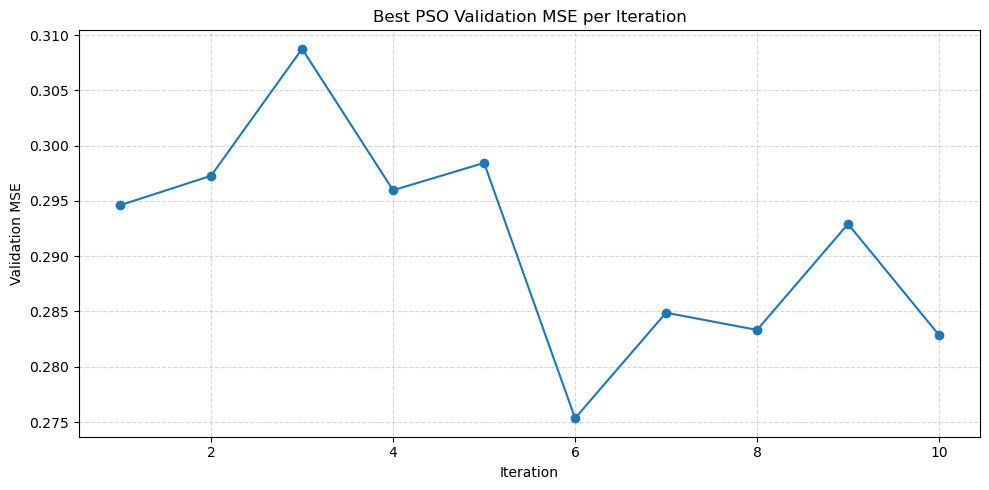

✅ STEP 10 COMPLETE


In [30]:
# ===============================================================
# 🧠 STEP 10: Review PSO Results (Optional but Recommended)
# ===============================================================

print("="*70)
print("🧠 STEP 10 START: Reviewing PSO results...")
print("="*70)

# Show top 10 particle evaluations
display_cols = [
    "iteration", "particle", "val_mse", "nb_filters", "kernel_size",
    "dropout_rate", "dilation_levels", "dense_units", "learning_rate", "batch_size"
]

top10 = pso_history_df.sort_values("val_mse", ascending=True).head(10)
print(top10[display_cols].to_string(index=False))

# Plot best score per iteration
best_per_iter = pso_history_df.groupby("iteration")["val_mse"].min()

plt.figure(figsize=(10, 5))
plt.plot(best_per_iter.index, best_per_iter.values, marker="o")
plt.title("Best PSO Validation MSE per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Validation MSE")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("✅ STEP 10 COMPLETE")

In [31]:
# ===============================================================
# 🧠 STEP 11: Train Final TCN Using Best PSO Hyperparameters
# ===============================================================

print("="*70)
print("🧠 STEP 11 START: Training final TCN with PSO-optimized parameters...")
print("="*70)

FINAL_EPOCHS = 100
FINAL_PATIENCE = 10

early_stop_final = EarlyStopping(
    monitor="val_loss",
    patience=FINAL_PATIENCE,
    restore_best_weights=True
)

final_model = build_tcn_model(global_best_params)

history_final = final_model.fit(
    X_train, y_train_seq,
    validation_split=0.2,
    epochs=FINAL_EPOCHS,
    batch_size=global_best_params["batch_size"],
    callbacks=[early_stop_final],
    verbose=1
)

print("✅ STEP 11 COMPLETE")

D:\ANACONDA\Lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


🧠 STEP 11 START: Training final TCN with PSO-optimized parameters...
Epoch 1/100
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - loss: 0.8746 - val_loss: 0.3775
Epoch 2/100
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - loss: 0.1344 - val_loss: 0.3327
Epoch 3/100
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.1283 - val_loss: 0.3213
Epoch 4/100
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.1271 - val_loss: 0.3012
Epoch 5/100
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.1243 - val_loss: 0.2991
Epoch 6/100
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.1238 - val_loss: 0.3038
Epoch 7/100
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.1212 - val_loss: 0.2952
Epoch 8/100
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.1211 - val_loss: 0.3019
Epoch 9/100
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.1199 - val_loss: 0.2868
Epoch 10/100
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.1189 - val_loss: 0.2858
Epoch 11/100
1146/11

In [32]:
# ===============================================================
# 🧠 STEP 12: Predict on Test Set and Inverse Transform
# ===============================================================

print("="*70)
print("🧠 STEP 12 START: Generating predictions...")
print("="*70)

# ---- Predict in scaled space ----
y_pred_scaled = final_model.predict(X_test, verbose=0)

# ---- Convert back to original units (kWh) ----
y_pred = y_scaler.inverse_transform(y_pred_scaled).reshape(-1, 1)
y_true = y_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).reshape(-1, 1)

# ---- Safety check ----
if len(y_pred) != len(y_true):
    raise ValueError(f"Prediction length mismatch: y_pred={len(y_pred)}, y_true={len(y_true)}")

print("Prediction shape:", y_pred.shape)
print("Ground truth shape:", y_true.shape)
print("✅ STEP 12 COMPLETE")

🧠 STEP 12 START: Generating predictions...
Prediction shape: (10361, 1)
Ground truth shape: (10361, 1)
✅ STEP 12 COMPLETE


In [33]:
# ===============================================================
# 🧠 STEP 13: Evaluate Model (MAE, RMSE, R², SMAPE)
# ===============================================================

print("="*70)
print("🧠 STEP 13 START: Evaluating PSO-TCN model...")
print("="*70)

def smape(y_t, y_p):
    y_t = np.asarray(y_t).flatten()
    y_p = np.asarray(y_p).flatten()
    denominator = (np.abs(y_t) + np.abs(y_p)) / 2.0
    ratio = np.abs(y_t - y_p) / np.maximum(denominator, 1e-8)
    return np.mean(ratio) * 100

# Flatten for sklearn metrics
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
r2 = r2_score(y_true_flat, y_pred_flat)
smape_val = smape(y_true_flat, y_pred_flat)

print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"R²    : {r2:.4f}")
print(f"SMAPE : {smape_val:.2f}%")

print("✅ STEP 13 COMPLETE")

🧠 STEP 13 START: Evaluating PSO-TCN model...
MAE   : 10.6448
RMSE  : 15.5294
R²    : 0.8587
SMAPE : 15.00%
✅ STEP 13 COMPLETE


🧠 STEP 14 START: Plotting full forecast...


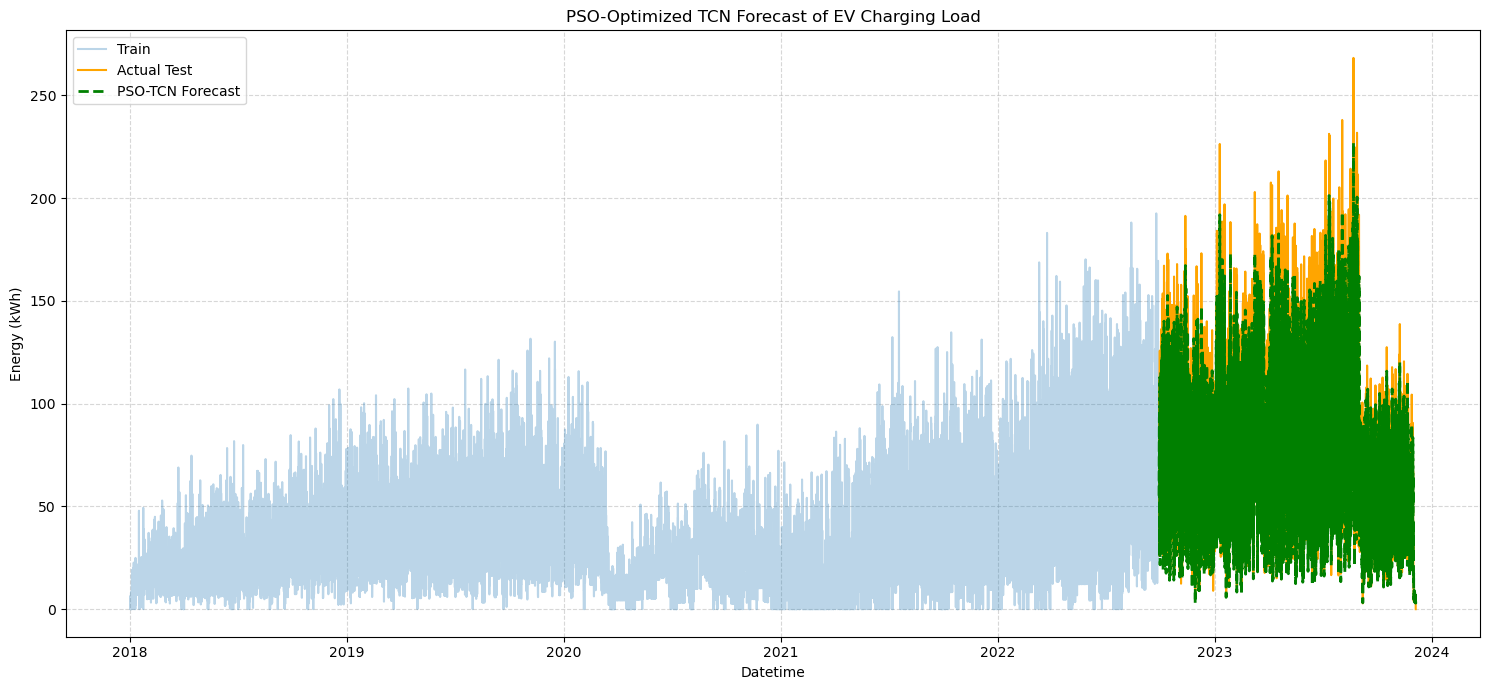

✅ STEP 14 COMPLETE


In [34]:
# ===============================================================
# 🧠 STEP 14: Plot Train, Actual Test, and PSO-TCN Forecast
# ===============================================================

print("="*70)
print("🧠 STEP 14 START: Plotting full forecast...")
print("="*70)

# Align test timestamps with predictions (skip first WINDOW_SIZE points)
test_aligned = test.iloc[WINDOW_SIZE:].copy()

if len(test_aligned) != len(y_pred_flat):
    # fallback alignment if needed
    min_len = min(len(test_aligned), len(y_pred_flat))
    test_aligned = test_aligned.iloc[:min_len]
    pred_aligned = y_pred_flat[:min_len]
else:
    pred_aligned = y_pred_flat

pred_series = pd.Series(pred_aligned, index=test_aligned.index, name="PSO_TCN_Forecast")

plt.figure(figsize=(15, 7))
plt.plot(train.index, train.values, label="Train", alpha=0.30)
plt.plot(test_aligned.index, test_aligned.values, label="Actual Test", color="orange")
plt.plot(pred_series.index, pred_series.values, label="PSO-TCN Forecast", color="green", linestyle="--", linewidth=2)

plt.title("PSO-Optimized TCN Forecast of EV Charging Load")
plt.xlabel("Datetime")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("✅ STEP 14 COMPLETE")

🧠 STEP 15 START: Plotting zoomed-in forecast (first 7 days)...


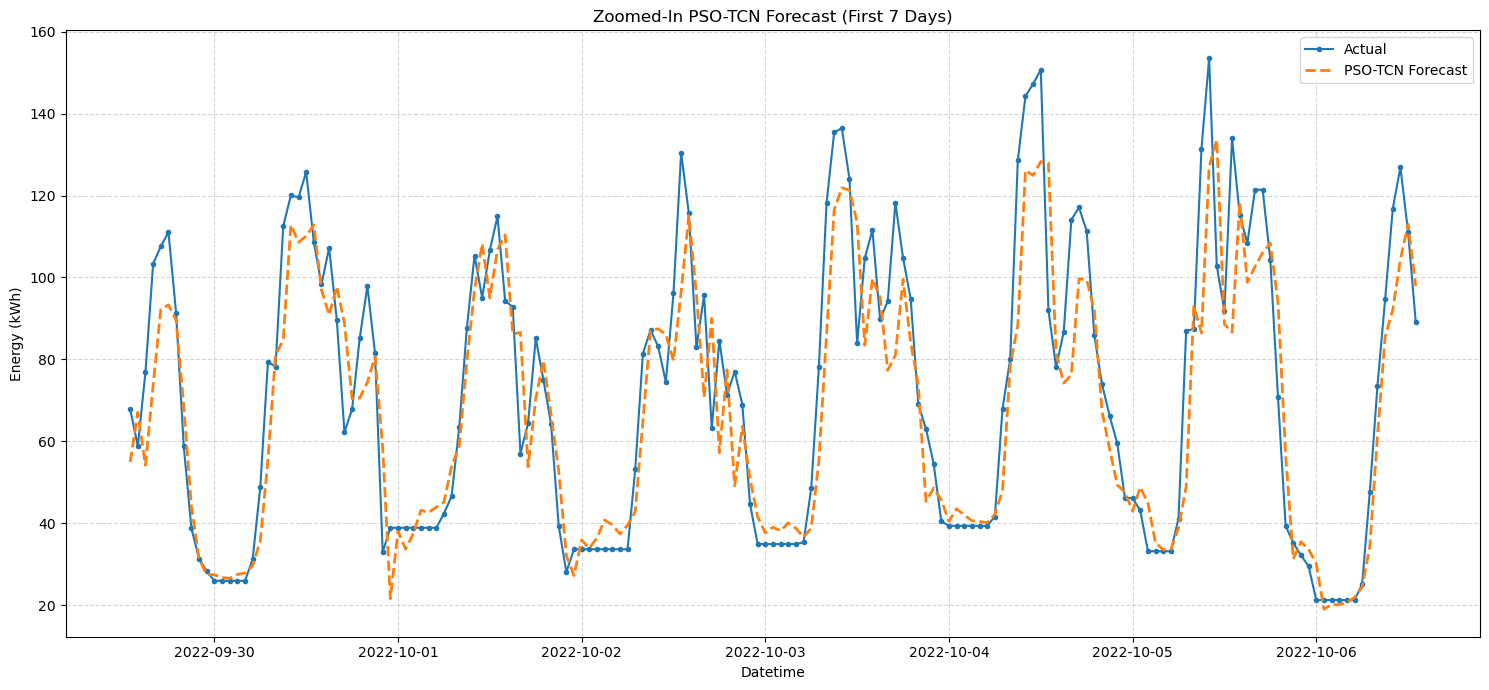

✅ STEP 15 COMPLETE


In [35]:
# ===============================================================
# 🧠 STEP 15: Plot Zoomed-In Forecast (First 7 Days of Test Predictions)
# ===============================================================

print("="*70)
print("🧠 STEP 15 START: Plotting zoomed-in forecast (first 7 days)...")
print("="*70)

zoom_days = 7
zoom_start_time = pred_series.index[0]
zoom_end_time = zoom_start_time + timedelta(days=zoom_days)

actual_zoom = test_aligned.loc[:zoom_end_time]
pred_zoom = pred_series.loc[:zoom_end_time]

plt.figure(figsize=(15, 7))
plt.plot(actual_zoom.index, actual_zoom.values, label="Actual", marker=".", linewidth=1.5)
plt.plot(pred_zoom.index, pred_zoom.values, label="PSO-TCN Forecast", linestyle="--", linewidth=2)

plt.title(f"Zoomed-In PSO-TCN Forecast (First {zoom_days} Days)")
plt.xlabel("Datetime")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("✅ STEP 15 COMPLETE")

In [36]:
# ===============================================================
# 🧠 STEP 16: Save Model and PSO Results
# ===============================================================

print("="*70)
print("🧠 STEP 16 START: Saving model and PSO logs...")
print("="*70)

# Save model in Keras format (avoids ResidualBlock .h5 issues)
final_model.save("TCN_PSO_optimized.keras")

# Save PSO history for reporting
pso_history_df.to_csv("pso_tcn_search_history.csv", index=False)

# Save best params summary
best_params_df = pd.DataFrame([{
    "best_val_mse": global_best_score,
    "nb_filters": global_best_params["nb_filters"],
    "kernel_size": global_best_params["kernel_size"],
    "dropout_rate": global_best_params["dropout_rate"],
    "dilations": str(global_best_params["dilations"]),
    "dense_units": global_best_params["dense_units"],
    "learning_rate": global_best_params["lr"],
    "batch_size": global_best_params["batch_size"]
}])
best_params_df.to_csv("pso_tcn_best_params.csv", index=False)

print("Saved:")
print("- TCN_PSO_optimized.keras")
print("- pso_tcn_search_history.csv")
print("- pso_tcn_best_params.csv")
print("✅ STEP 16 COMPLETE — PIPELINE FINISHED SUCCESSFULLY")
print("="*70)

🧠 STEP 16 START: Saving model and PSO logs...
Saved:
- TCN_PSO_optimized.keras
- pso_tcn_search_history.csv
- pso_tcn_best_params.csv
✅ STEP 16 COMPLETE — PIPELINE FINISHED SUCCESSFULLY
